In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# Sample sales data
df_sales = pd.DataFrame({
    "region": ["North", "South", "East", "West", "Central"],
    "jan": [12400, 9800, 15200, 8700, 11300],
    "feb": [13100, 10500, 14800, 9200, 12100],
    "mar": [14500, 11200, 16300, 10100, 13400],
    "apr": [13800, 10900, 15700, 9600, 12800],
    "may": [15200, 11800, 17100, 10400, 14200],
    "jun": [16000, 12400, 18500, 11000, 15600]
})

months_cols = ["jan", "feb", "mar", "apr", "may", "jun"]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

df_sales["total_sales"] = df_sales[months_cols].sum(axis=1)

print(df_sales)

    region    jan    feb    mar    apr    may    jun  total_sales
0    North  12400  13100  14500  13800  15200  16000        85000
1    South   9800  10500  11200  10900  11800  12400        66600
2     East  15200  14800  16300  15700  17100  18500        97600
3     West   8700   9200  10100   9600  10400  11000        59000
4  Central  11300  12100  13400  12800  14200  15600        79400


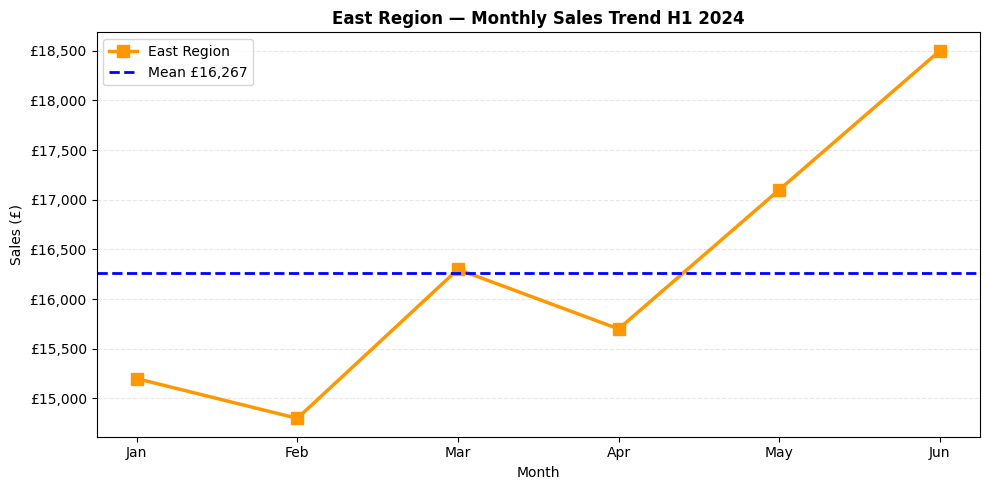

In [4]:
# Get EAST region sales
east_sales = df_sales.loc[df_sales["region"] == "East", months_cols].values[0]

# Calculate mean
east_mean = east_sales.mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    months,
    east_sales,
    color="#FF9800",
    marker="s",
    markerfacecolor="#FF9800",
    markeredgecolor="#FF9800",
    linewidth=2.5,
    markersize=8,
    label="East Region"
)

ax.axhline(
    east_mean,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean £{east_mean:,.0f}"
)

ax.set_title("East Region — Monthly Sales Trend H1 2024", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Sales (£)")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

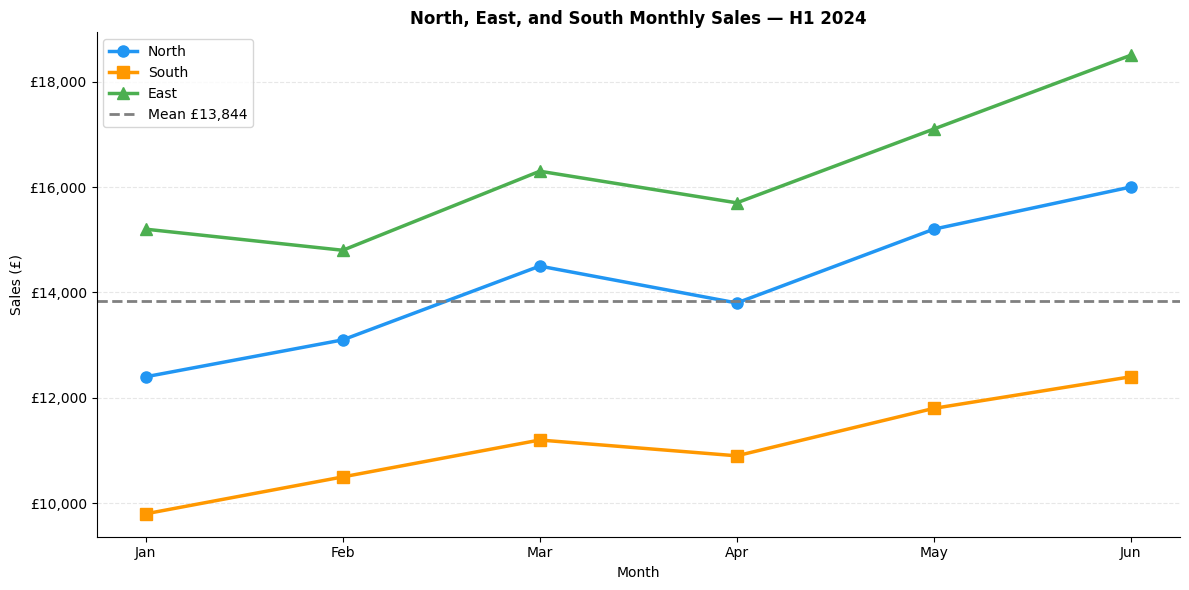

In [5]:
# Filter selected regions
df_top = df_sales[df_sales["region"].isin(["North", "East", "South"])]

colours = ["#2196F3", "#FF9800", "#4CAF50"]
markers = ["o", "s", "^"]

fig, ax = plt.subplots(figsize=(12, 6))

for i, row in df_top.iterrows():
    color_index = list(df_top.index).index(i)

    ax.plot(
        months,
        row[months_cols],
        color=colours[color_index],
        marker=markers[color_index],
        linewidth=2.5,
        markersize=8,
        label=row["region"]
    )

# Mean of the selected 3 regions
top_mean = df_top[months_cols].values.mean()

ax.axhline(
    top_mean,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Mean £{top_mean:,.0f}"
)

ax.set_title("North, East, and South Monthly Sales — H1 2024", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Sales (£)")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

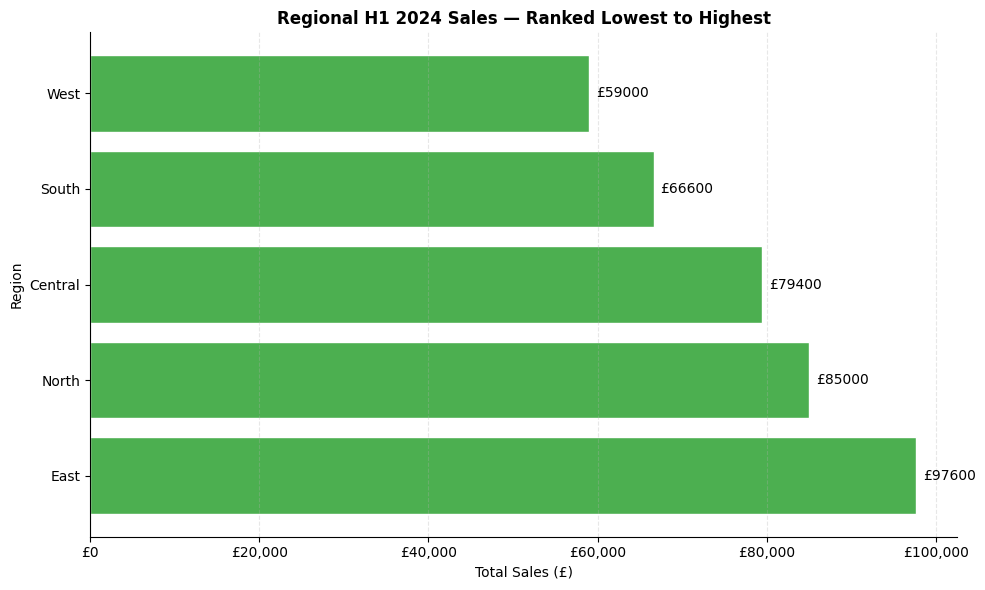

In [6]:
# Sort sales from lowest to highest
df_sorted = df_sales.sort_values("total_sales", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_sorted["region"],
    df_sorted["total_sales"],
    color="#4CAF50",
    edgecolor="white"
)

ax.bar_label(
    bars,
    fmt="£%.0f",
    padding=5,
    fontsize=10
)

ax.set_title("Regional H1 2024 Sales — Ranked Lowest to Highest", fontweight="bold")
ax.set_xlabel("Total Sales (£)")
ax.set_ylabel("Region")

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

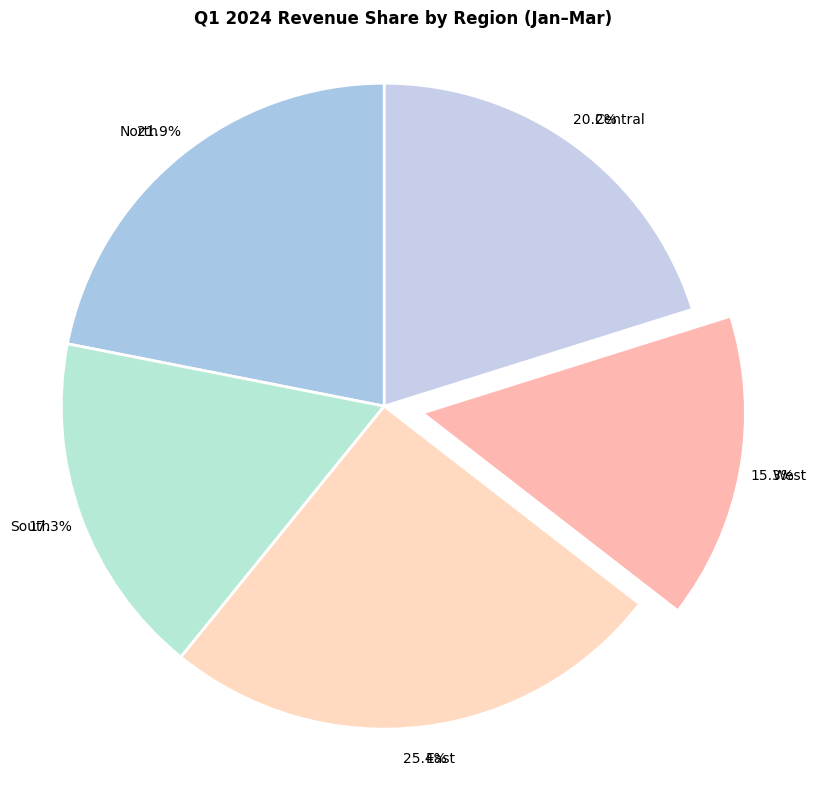

In [7]:
# Create Q1 sales column
df_sales["q1_sales"] = df_sales[["jan", "feb", "mar"]].sum(axis=1)

# Explode West slice only
explode = [0, 0, 0, 0.12, 0]

pastel_colours = ["#A7C7E7", "#B5EAD7", "#FFDAC1", "#FFB7B2", "#C7CEEA"]

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    df_sales["q1_sales"],
    labels=df_sales["region"],
    autopct="%1.1f%%",
    pctdistance=1.1,
    colors=pastel_colours,
    explode=explode,
    startangle=90,
    wedgeprops={"linewidth": 2, "edgecolor": "white"}
)

ax.set_title("Q1 2024 Revenue Share by Region (Jan–Mar)", fontweight="bold")

plt.axis("equal")
plt.tight_layout()
plt.show()

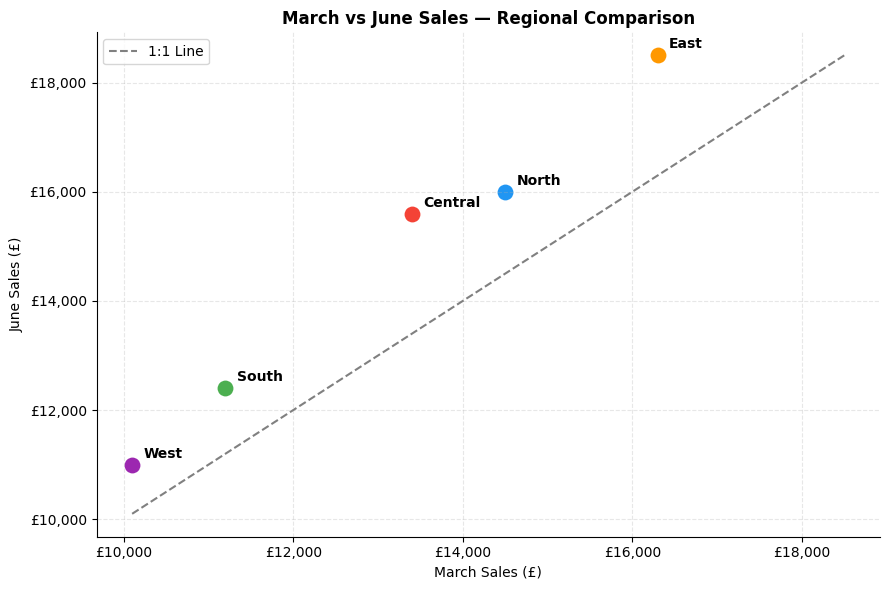

In [8]:
colours = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

fig, ax = plt.subplots(figsize=(9, 6))

for i, row in df_sales.iterrows():
    ax.scatter(
        row["mar"],
        row["jun"],
        color=colours[i],
        s=180,
        edgecolors="white",
        linewidths=2
    )

    ax.annotate(
        row["region"],
        xy=(row["mar"], row["jun"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=10,
        fontweight="bold"
    )

# 1:1 reference line
min_value = min(df_sales["mar"].min(), df_sales["jun"].min())
max_value = max(df_sales["mar"].max(), df_sales["jun"].max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="gray",
    linestyle="--",
    label="1:1 Line"
)

ax.set_title("March vs June Sales — Regional Comparison", fontweight="bold")
ax.set_xlabel("March Sales (£)")
ax.set_ylabel("June Sales (£)")

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax.legend()
ax.grid(linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

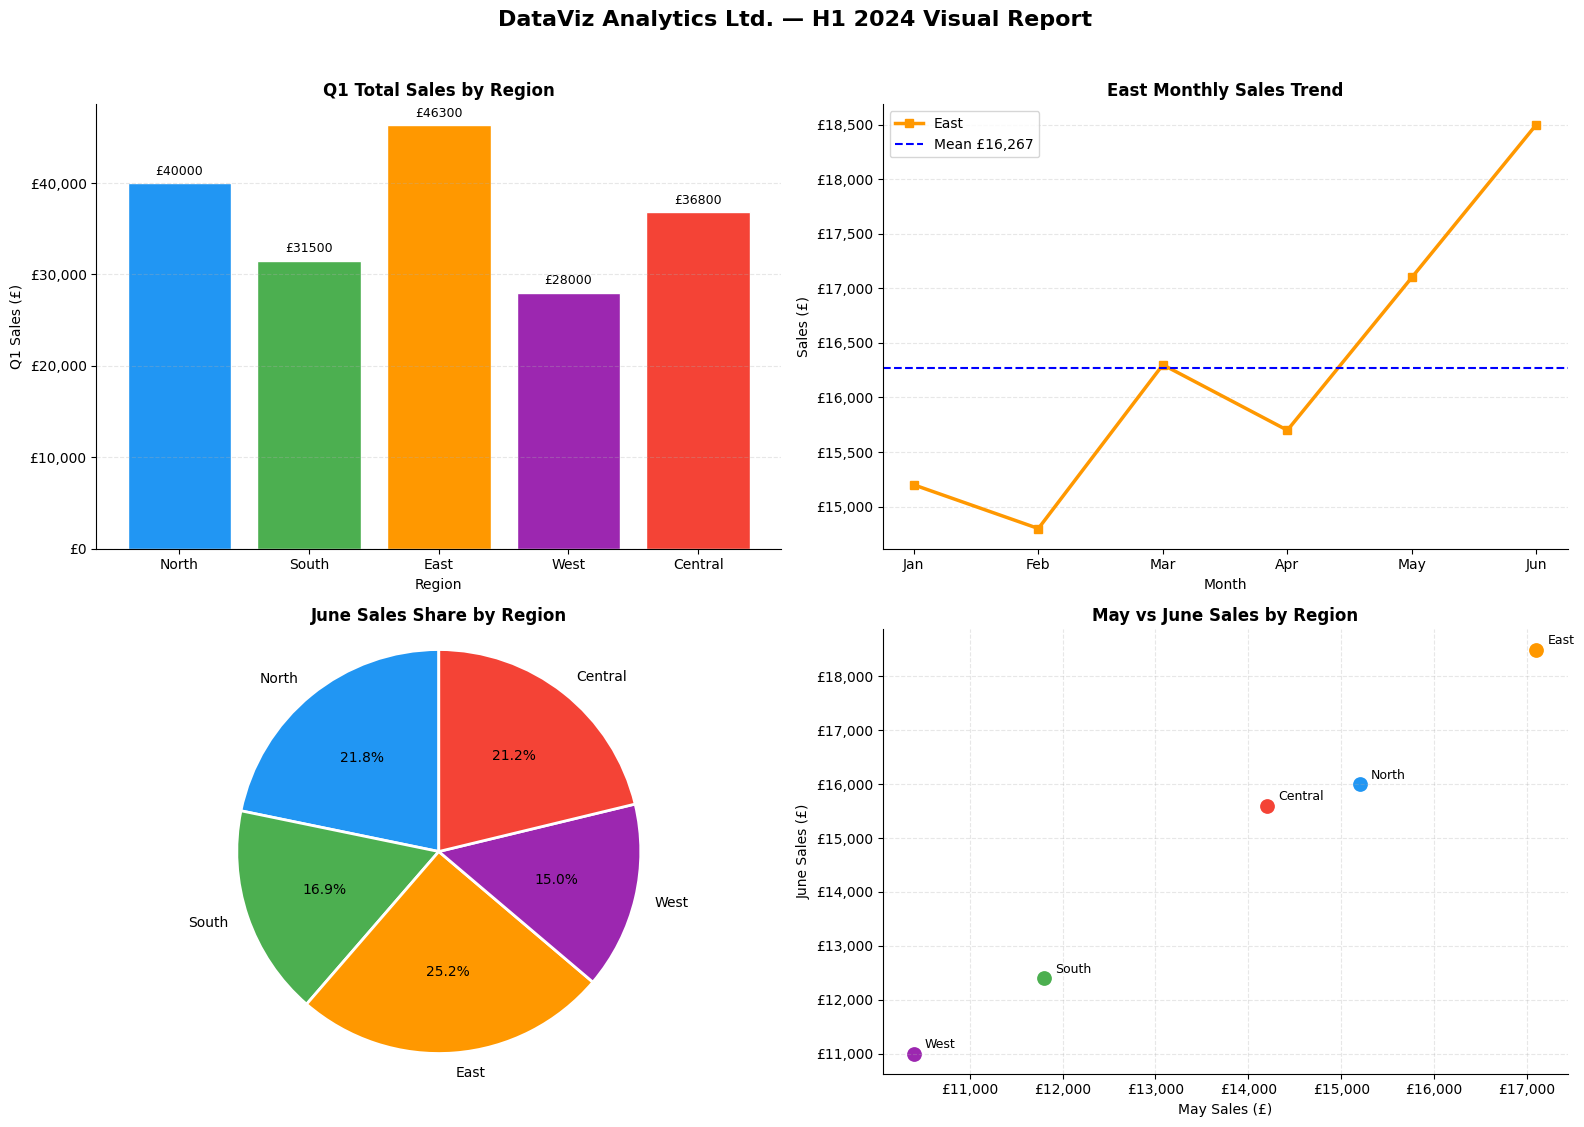

In [9]:
# Make sure Q1 sales exists
df_sales["q1_sales"] = df_sales[["jan", "feb", "mar"]].sum(axis=1)

colours = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

ax1, ax2, ax3, ax4 = axes.flatten()

# Top-left: Bar chart — Q1 total sales per region
bars = ax1.bar(
    df_sales["region"],
    df_sales["q1_sales"],
    color=colours,
    edgecolor="white"
)

ax1.bar_label(bars, fmt="£%.0f", padding=4, fontsize=9)
ax1.set_title("Q1 Total Sales by Region", fontweight="bold")
ax1.set_xlabel("Region")
ax1.set_ylabel("Q1 Sales (£)")
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Top-right: Line chart — EAST region monthly trend
east_sales = df_sales.loc[df_sales["region"] == "East", months_cols].values[0]
east_mean = east_sales.mean()

ax2.plot(
    months,
    east_sales,
    color="#FF9800",
    marker="s",
    markerfacecolor="#FF9800",
    linewidth=2.5,
    label="East"
)

ax2.axhline(
    east_mean,
    color="blue",
    linestyle="--",
    label=f"Mean £{east_mean:,.0f}"
)

ax2.set_title("East Monthly Sales Trend", fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Sales (£)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Bottom-left: Pie chart — June sales share
ax3.pie(
    df_sales["jun"],
    labels=df_sales["region"],
    autopct="%1.1f%%",
    colors=colours,
    startangle=90,
    wedgeprops={"linewidth": 2, "edgecolor": "white"}
)

ax3.set_title("June Sales Share by Region", fontweight="bold")
ax3.axis("equal")

# Bottom-right: Scatter — May sales vs June sales
for i, row in df_sales.iterrows():
    ax4.scatter(
        row["may"],
        row["jun"],
        color=colours[i],
        s=160,
        edgecolors="white",
        linewidths=2
    )

    ax4.annotate(
        row["region"],
        xy=(row["may"], row["jun"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9
    )

ax4.set_title("May vs June Sales by Region", fontweight="bold")
ax4.set_xlabel("May Sales (£)")
ax4.set_ylabel("June Sales (£)")

ax4.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax4.grid(linestyle="--", alpha=0.3)

# Clean chart borders
for ax in [ax1, ax2, ax4]:
    ax.spines[["top", "right"]].set_visible(False)

# Overall dashboard title
plt.suptitle(
    "DataViz Analytics Ltd. — H1 2024 Visual Report",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# Save the dashboard
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")

plt.show()